# What Makes a Track Popular on Spotify?

**An exploratory data analysis of 114,000 Spotify tracks across 114 genres.**

**Question:** What makes a track popular on Spotify, and which audio features (energy, danceability, loudness...) are most strongly correlated between each other and with `popularity`?

Dataset: [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (Kaggle), 114,000 rows, 21 columns.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('dataset.csv')
df.shape

(114000, 21)

## 2. Data Understanding

A first look at the shape, columns, and data types before touching anything.

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


In [6]:
df[['artists', 'album_name', 'track_name', 'track_genre']].nunique()

artists        31437
album_name     46589
track_name     73608
track_genre      114
dtype: int64

## 3. Data Cleaning

Three things need handling before analysis:
- **Missing values** — a small number of rows are missing text metadata.
- **Duplicate rows** — some tracks are exact duplicates (same `track_id` appears more than once with identical data).
- **The multi-genre quirk** — after removing exact duplicates, many `track_id`s *still* repeat. This isn't an error: the same song is tagged under several genres in this dataset (e.g. a track can appear once as "pop" and once as "k-pop"). Each row represents a *(track, genre)* pairing, not a unique song. 

In [7]:
df.isna().sum()[df.isna().sum() > 0]

artists       1
album_name    1
track_name    1
dtype: int64

In [8]:
# checking to see the row with the missing artist data. Notice here that 1 row is missing artist/album/track_name metadata — we drop it, as we can't use it for
# anything (genre and audio features are unaffected either way, but it's not analytically useful)
df.loc[df['artists'].isna(), ['artists', 'album_name', 'track_name']]

,artists,album_name,track_name
65900,NaN,NaN,NaN


In [9]:
df = df.dropna(subset=['artists']).copy()
df.shape

(113999, 21)

In [10]:
# Drop columns we won't use: the redundant index column, and free-text names, as they're not important for the analysis
df = df.drop(columns=['Unnamed: 0', 'track_name', 'album_name'])

In [11]:
# Exact duplicate rows (every column identical) — safe to drop
print(f"Exact duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
df.shape

Exact duplicate rows: 450


(113549, 18)

In [12]:
# track_id still repeats — this is the multi-genre quirk, not an error.
# Example below: same song, tagged under multiple genres
example_id = df.loc[df.duplicated(subset=['track_id']), 'track_id'].iloc[0]
df.loc[df['track_id'] == example_id, ['track_id', 'artists', 'track_genre', 'popularity']]

,track_id,artists,track_genre,popularity
2000,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,alt-rock,87
3000,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,alternative,87
91100,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,rock,87


In [13]:
#converting duration from milliseconds to minutes for readability.
df['duration_min'] = df['duration_ms'] / 60000
df = df.drop(columns=['duration_ms'])
df.shape

(113549, 18)

## 4. Univariate Analysis

First, we get a feel for the shape of each key variable that could be linked to the popularity variable before looking at relationships between them.

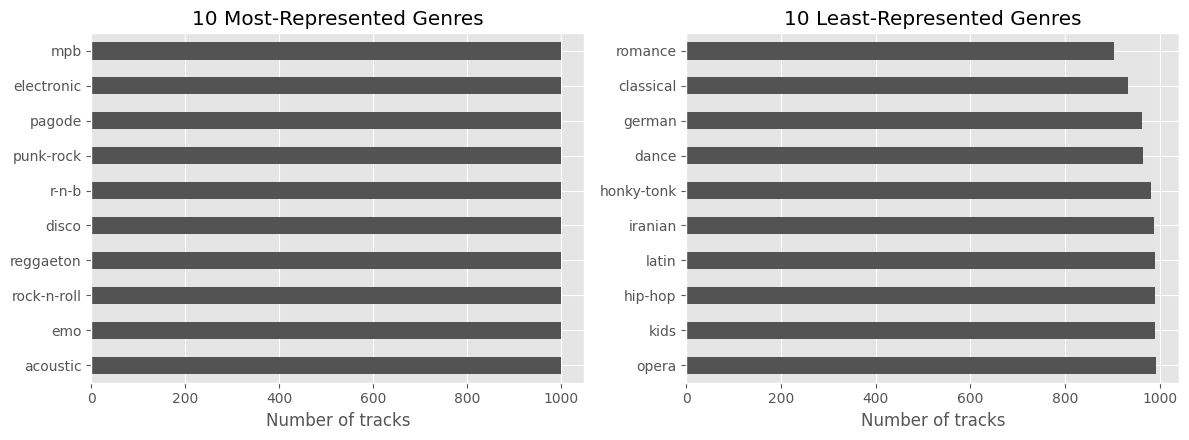

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['track_genre'].value_counts().head(10).plot(kind='barh', ax= axes[0], color='#535353')
axes[0].set_title('10 Most-Represented Genres')
axes[0].set_xlabel('Number of tracks')
axes[0].set_ylabel('')

df['track_genre'].value_counts().tail(10).plot(kind='barh', ax= axes[1], color='#535353')
axes[1].set_title('10 Least-Represented Genres')
axes[1].set_xlabel('Number of tracks')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The above tells us that genres are near-perfectly balanced by design (~1,000 tracks each), so genre-level comparisons are fair without needing to correct for sample size.

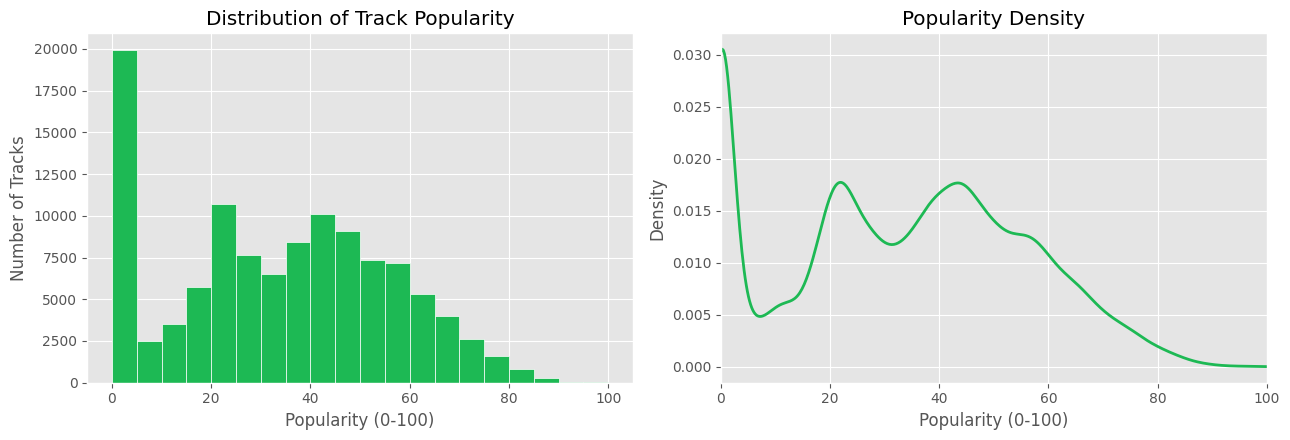

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['popularity'].plot(kind='hist', bins=20, ax=axes[0], color='#1DB954', edgecolor='white')
axes[0].set_title('Distribution of Track Popularity')
axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Number of Tracks')

df['popularity'].plot(kind='kde', ax=axes[1], color='#1DB954', linewidth=2)
axes[1].set_title('Popularity Density')
axes[1].set_xlabel('Popularity (0-100)')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

We can see the track popularity is slightly skewed to the right, and multi-modal. The single largest cluster of songs fall in the 0-5 popularity range, which is followed by spikes in the 20-25 and 40-45 ranges.

In [16]:
print(f"Mean popularity: {df['popularity'].mean():.1f}")
print(f"Median popularity: {df['popularity'].median():.1f}")
print(f"Tracks with popularity = 0: {(df['popularity'] == 0).sum():,} ({(df['popularity'] == 0).mean():.1%})")
most_popular_track = df.loc[df['popularity'].idxmax()]
print(f"The track with the highest popularity score in the dataset: {most_popular_track['track_id']} (track name - unholy)")
df.loc[df['popularity'] == 100]

Mean popularity: 33.3
Median popularity: 35.0
Tracks with popularity = 0: 15,843 (14.0%)
The track with the highest popularity score in the dataset: 3nqQXoyQOWXiESFLlDF1hG (track name - unholy)


,track_id,artists,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,dance,2.615717
81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,pop,2.615717


In [17]:
df.groupby('key')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False).round(2)

,mean,count
key,,
4,34.74,8971
2,34.48,11594
11,33.96,9251
6,33.66,7891
1,33.26,10740
3,33.19,3548
5,33.02,9325
8,33.02,7337
9,32.91,11264


Tracks with a key of E are on average the most popular. However, average popularity varies very little by key.

In [18]:
df.sort_values(by='popularity', ascending=False).drop_duplicates(subset='track_id').head(10)[['track_id', 'artists', 'popularity', 'track_genre']]

,track_id,artists,popularity,track_genre
81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,100,pop
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,99,hip-hop
68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,98,latino
81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,98,pop
88405,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,97,reggae
88407,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,97,reggae
79000,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,96,piano
20000,5IgjP7X4th6nMNDh4akUHb,Chris Brown,96,dance
67559,5Eax0qFko2dh7Rl2lYs3bx,Bad Bunny,96,latin
81052,4LRPiXqCikLlN15c3yImP7,Harry Styles,95,pop


Above are the 10 most popular tracks in the dataset. Track titles aren't included.

In [19]:
df.groupby('explicit')['popularity'].agg('count').sort_values(ascending= False).round(2)

explicit
False    103831
True       9718
Name: popularity, dtype: int64

The majority of tracks in our dataset aren't explicit (~10.7:1 ratio of non-explicit to explicit tracks).

In [20]:
df.groupby('mode')['popularity'].agg('count').sort_values(ascending= False).round(2)

mode
1    72429
0    41120
Name: popularity, dtype: int64

Most are in a major key (1.76:1 ratio of major to minor tracks).

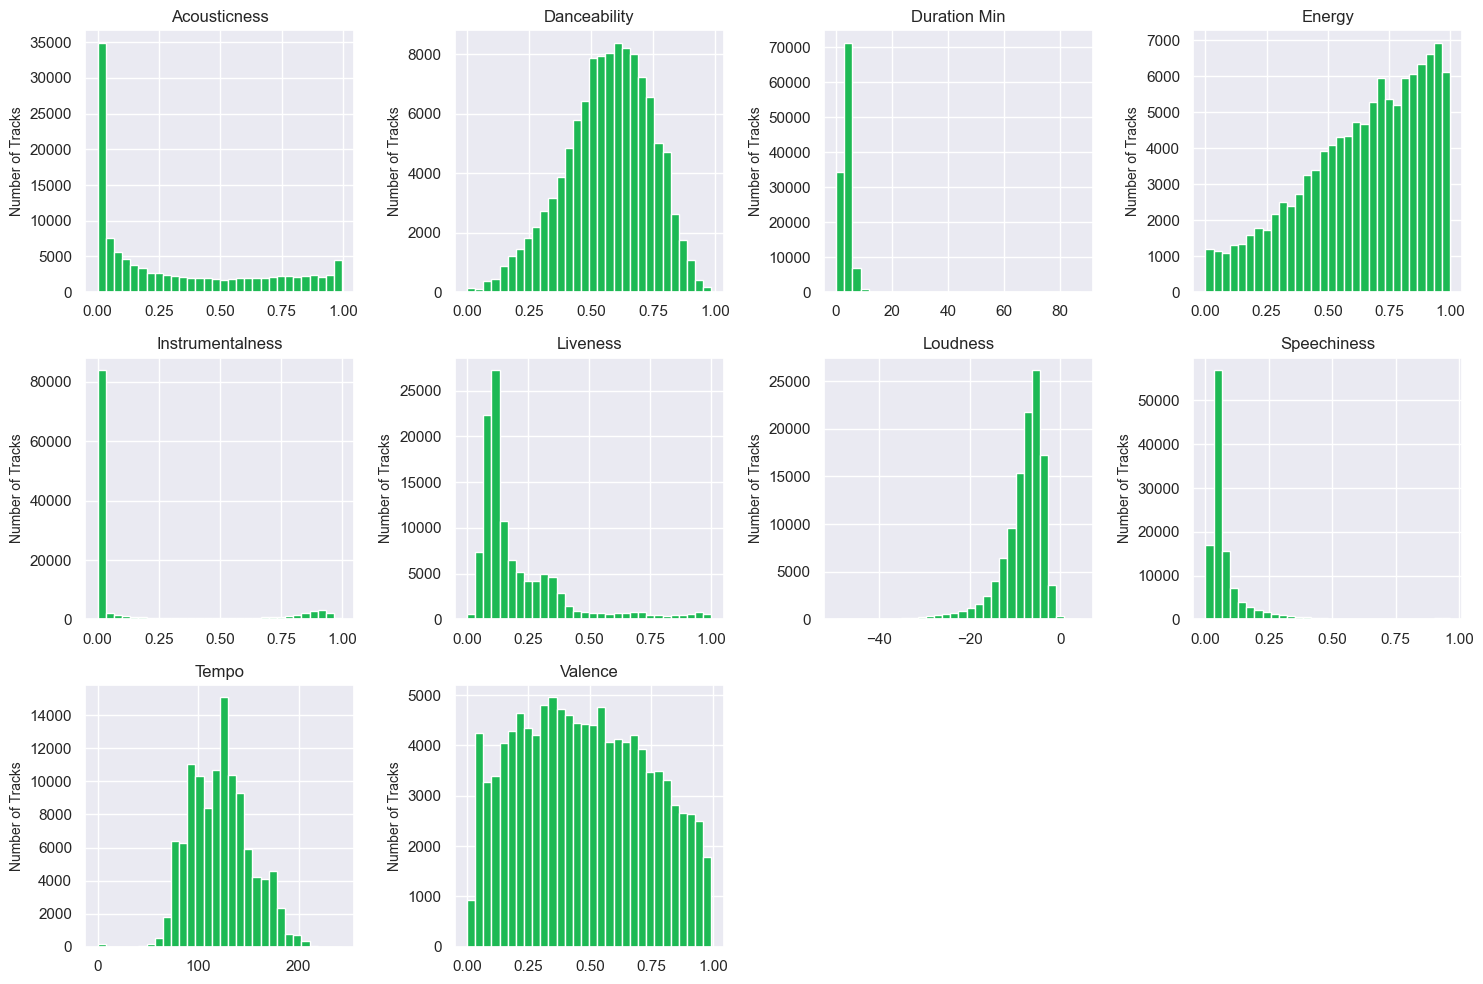

In [21]:
import math

sns.set_theme()  # applies seaborn's default grey/white-gridline look

exclude_cols = ['popularity', 'mode', 'time_signature', 'key']
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude_cols)

n = len(numeric_cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], color='#1DB954', edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Number of Tracks', fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Several of the distributions are skewed rather than normal, and valence shows quite a uniform distribution. Interestingly, the distribution of instrumentalness has a secondary smaller spike between 0.75 and 1, which we can investigate. 

Likewise, the tempo distribution shows some tracks at very low tempos, which is worth double checking for outliers.

In [22]:
df_high_speechiness = df[df['speechiness'] > 0.66]
overall = df['track_genre'].value_counts(normalize=True)
spike = df_high_speechiness['track_genre'].value_counts(normalize=True)

comparison = pd.DataFrame({'overall': overall, 'in_spike': spike}).fillna(0)
comparison['ratio'] = comparison['in_spike'] / comparison['overall']
comparison.sort_values('ratio', ascending=False).head(10)

,overall,in_spike,ratio
track_genre,,,
comedy,0.008772,0.872146,99.429036
kids,0.008728,0.012557,1.438793
children,0.008789,0.011416,1.298819
show-tunes,0.008798,0.011416,1.297519
funk,0.008807,0.010274,1.166599
jazz,0.008798,0.005708,0.648759
j-dance,0.008745,0.004566,0.522144
chill,0.008798,0.004566,0.519008
garage,0.008807,0.004566,0.518489


Investigating the high-speechiness spike (>0.66) revealed it was driven almost entirely by the comedy genre (764 tracks, ~87% of the subset vs. 0.88% baseline — a ~99x over-representation), consistent with spoken-word content rather than a data issue. Therefore, no outliers to remove.

In [23]:
df_low_tempo = df[df['tempo'] < 40]
overall = df['track_genre'].value_counts(normalize=True)
spike_low_tempo = df_low_tempo['track_genre'].value_counts(normalize=True)

comparison_low_tempo = pd.DataFrame({'overall': overall, 'in_spike': spike_low_tempo}).fillna(0)
comparison_low_tempo['ratio'] = comparison_low_tempo['in_spike'] / comparison_low_tempo['overall']
comparison_low_tempo.sort_values('ratio', ascending=False).head(10)

,overall,in_spike,ratio
track_genre,,,
sleep,0.008807,0.810345,92.013845
iranian,0.008701,0.028736,3.302533
ambient,0.008798,0.022989,2.612935
guitar,0.008798,0.022989,2.612935
world-music,0.008798,0.022989,2.612935
study,0.008789,0.017241,1.961665
opera,0.008736,0.011494,1.315686
comedy,0.008772,0.011494,1.310403
show-tunes,0.008798,0.011494,1.306467


Investigating the low-tempo spike (<40) revealed it was driven almost entirely by the sleep genre (1000 tracks, ~81% of the subset vs. 0.88% baseline — a ~92x over-representation), consistent with slow music which may have an unrecognisable tempo rather than a data issue. Therefore, no outliers to remove.

## 5. Grouping 114 Genres into 10 Families

114 micro-genres (`acoustic`, `detroit-techno`, `j-idol`...) is too granular to compare visually. I mapped each to one of 10 broader families to make genre-level patterns readable, while keeping the original `track_genre` column for anyone who wants the fine-grained view.

In [24]:
genre_to_bucket = {
    # Rock/Metal
    'rock': 'Rock/Metal', 'alt-rock': 'Rock/Metal', 'alternative': 'Rock/Metal',
    'hard-rock': 'Rock/Metal', 'punk': 'Rock/Metal', 'punk-rock': 'Rock/Metal',
    'metal': 'Rock/Metal', 'metalcore': 'Rock/Metal', 'heavy-metal': 'Rock/Metal',
    'death-metal': 'Rock/Metal', 'black-metal': 'Rock/Metal', 'grindcore': 'Rock/Metal',
    'grunge': 'Rock/Metal', 'psych-rock': 'Rock/Metal', 'rockabilly': 'Rock/Metal',
    'rock-n-roll': 'Rock/Metal', 'emo': 'Rock/Metal', 'goth': 'Rock/Metal',
    'industrial': 'Rock/Metal', 'ska': 'Rock/Metal', 'hardcore': 'Rock/Metal',

    # Electronic/Dance
    'edm': 'Electronic/Dance', 'electro': 'Electronic/Dance', 'electronic': 'Electronic/Dance',
    'house': 'Electronic/Dance', 'deep-house': 'Electronic/Dance', 'chicago-house': 'Electronic/Dance',
    'detroit-techno': 'Electronic/Dance', 'techno': 'Electronic/Dance', 'trance': 'Electronic/Dance',
    'progressive-house': 'Electronic/Dance', 'minimal-techno': 'Electronic/Dance', 'dubstep': 'Electronic/Dance',
    'dub': 'Electronic/Dance', 'drum-and-bass': 'Electronic/Dance', 'breakbeat': 'Electronic/Dance',
    'idm': 'Electronic/Dance', 'hardstyle': 'Electronic/Dance', 'trip-hop': 'Electronic/Dance',
    'garage': 'Electronic/Dance', 'club': 'Electronic/Dance', 'dance': 'Electronic/Dance',
    'disco': 'Electronic/Dance',

    # Pop
    'pop': 'Pop', 'pop-film': 'Pop', 'power-pop': 'Pop', 'synth-pop': 'Pop',
    'indie-pop': 'Pop', 'indie': 'Pop', 'k-pop': 'Pop', 'cantopop': 'Pop',
    'mandopop': 'Pop', 'j-pop': 'Pop',

    # Hip-Hop/R&B
    'hip-hop': 'Hip-Hop/R&B', 'r-n-b': 'Hip-Hop/R&B', 'funk': 'Hip-Hop/R&B',
    'soul': 'Hip-Hop/R&B', 'reggaeton': 'Hip-Hop/R&B', 'reggae': 'Hip-Hop/R&B',
    'dancehall': 'Hip-Hop/R&B',

    # Classical/Instrumental
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental',
    'piano': 'Classical/Instrumental', 'new-age': 'Classical/Instrumental',
    'ambient': 'Classical/Instrumental', 'guitar': 'Classical/Instrumental',

    # Country/Folk/Acoustic
    'acoustic': 'Country/Folk/Acoustic', 'country': 'Country/Folk/Acoustic',
    'folk': 'Country/Folk/Acoustic', 'bluegrass': 'Country/Folk/Acoustic',
    'honky-tonk': 'Country/Folk/Acoustic', 'singer-songwriter': 'Country/Folk/Acoustic',
    'songwriter': 'Country/Folk/Acoustic', 'happy': 'Country/Folk/Acoustic',

    # Jazz/Blues
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues', 'groove': 'Jazz/Blues',

    # World/Regional
    'afrobeat': 'World/Regional', 'brazil': 'World/Regional', 'british': 'World/Regional',
    'french': 'World/Regional', 'german': 'World/Regional', 'indian': 'World/Regional',
    'iranian': 'World/Regional', 'j-dance': 'World/Regional', 'j-idol': 'World/Regional',
    'j-rock': 'World/Regional', 'latin': 'World/Regional', 'latino': 'World/Regional',
    'malay': 'World/Regional', 'mpb': 'World/Regional', 'pagode': 'World/Regional',
    'party': 'World/Regional', 'romance': 'World/Regional', 'salsa': 'World/Regional',
    'samba': 'World/Regional', 'sertanejo': 'World/Regional', 'spanish': 'World/Regional',
    'swedish': 'World/Regional', 'tango': 'World/Regional', 'turkish': 'World/Regional',
    'world-music': 'World/Regional', 'gospel': 'World/Regional', 'forro': "World/Regional",

    # Functional/Non-Music
    'children': 'Functional/Non-Music', 'kids': 'Functional/Non-Music',
    'disney': 'Functional/Non-Music', 'sleep': 'Functional/Non-Music',
    'study': 'Functional/Non-Music', 'show-tunes': 'Functional/Non-Music',
    'anime': 'Functional/Non-Music',

    # Alternative/Other
    'chill': 'Alternative/Other', 'comedy': 'Alternative/Other', 'sad': 'Alternative/Other',
}

df['genre_family'] = df['track_genre'].map(genre_to_bucket)

# sanity check: every genre should have been mapped
unmapped = set(df['track_genre'].unique()) - set(genre_to_bucket.keys())
print(f"Unmapped genres: {unmapped}")
df['genre_family'].value_counts()

Unmapped genres: set()


genre_family
World/Regional            26811
Electronic/Dance          21926
Rock/Metal                20977
Pop                        9980
Country/Folk/Acoustic      7977
Hip-Hop/R&B                6989
Functional/Non-Music       6984
Classical/Instrumental     5915
Jazz/Blues                 2995
Alternative/Other          2995
Name: count, dtype: int64

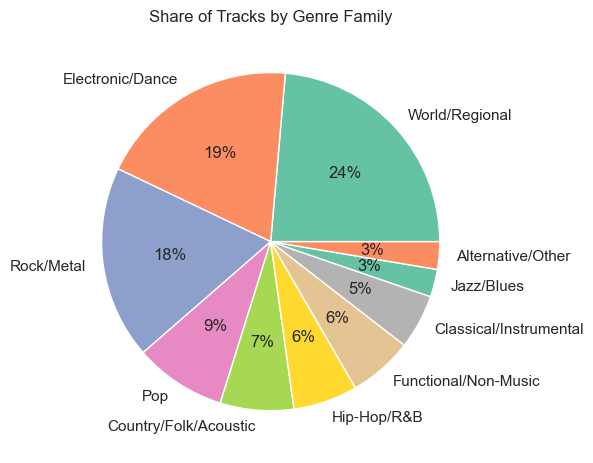

In [25]:
df['genre_family'].value_counts().plot(
    kind='pie', autopct='%1.0f%%', figsize=(6, 6), ylabel='',
    colors=sns.color_palette('Set2', 10)
)
plt.title('Share of Tracks by Genre Family')
plt.tight_layout()
plt.show()

## 6. Feature Relationships: What Correlates with Popularity?

We look at the Pearson correlation coefficient (r score) to measure the linear relationship among and between audio features and popularity scores.

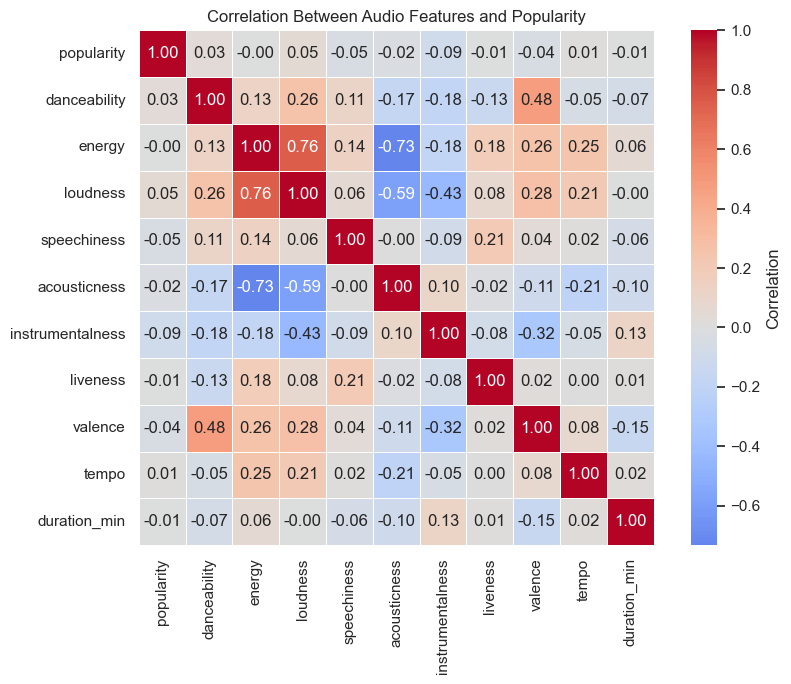

In [26]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                   'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']

corr_cols = ['popularity'] + audio_features
df_corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Audio Features and Popularity')
plt.tight_layout()
plt.show()

We can see that a track's loudness and energy have the strongest linear relationship (r score of 0.76), followed by valence and danceability (r score of 0.48). On the other hand, acousticness and energy share a strong negative relationship (r score of -0.73). The next most negative linear relationship is between acousticness and loudness (r score of -0.59).

In [27]:
df_corr['popularity'].drop('popularity').sort_values(key=abs, ascending=False)

instrumentalness   -0.094718
loudness            0.047368
speechiness        -0.045463
valence            -0.041097
danceability        0.034407
acousticness       -0.022356
tempo               0.012187
duration_min       -0.007928
liveness           -0.005668
energy             -0.002447
Name: popularity, dtype: float64

We can see that the correlations between the audio features and track popularity are weak — the strongest is instrumentalness at roughly -0.09, and none exceed 0.1 in magnitude. No single audio feature predicts popularity in a straightforward way. 

This could be for a few reasons:

1) This analysis only rules out *linear* relationships between audio features and popularity. Some features may still affect popularity non-linearly — for example, moderate danceability or energy could be more popular than either extreme (a "sweet spot" effect). A simple correlation coefficient wouldn't capture this.

2) Popularity could be driven by something *other than* the raw sound profile of a track — most likely artist fame, marketing, playlist placement, and release recency, none of which are captured in this dataset.

3) A feature might only matter when combined with another (e.g. high energy might only help within certain genres, or danceability might only matter for tracks under 3 minutes). Pairwise correlation can't uncover combinations like that.

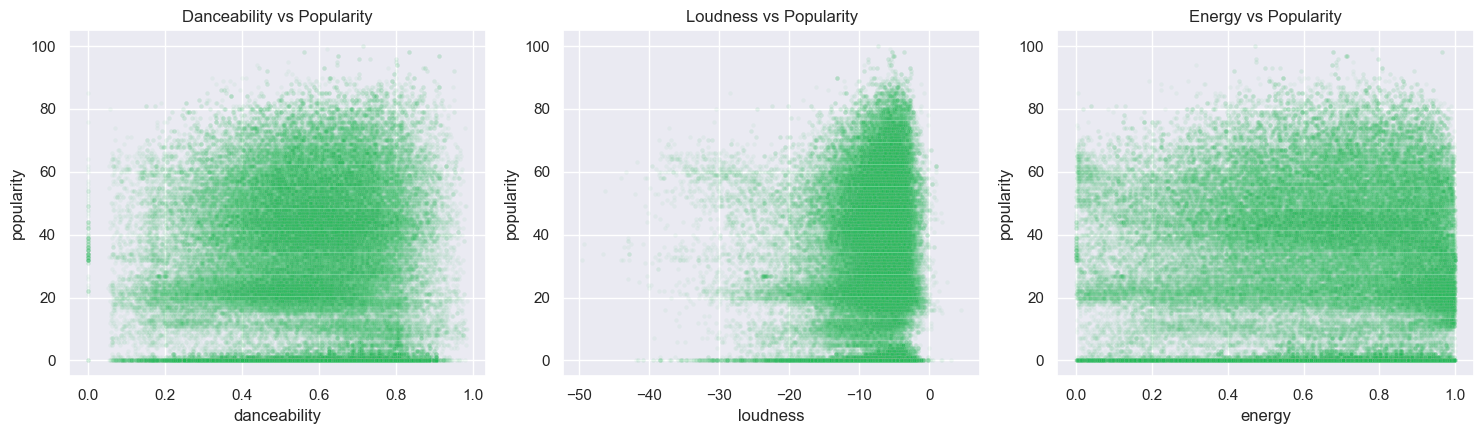

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, feat in zip(axes, ['danceability', 'loudness', 'energy']):
    sns.scatterplot(data=df, x=feat, y='popularity', ax=ax, alpha=0.05, s=10, color='#1DB954')
    ax.set_title(f'{feat.capitalize()} vs Popularity')

plt.tight_layout()
plt.show()

The scatterplots above confirm it visually - dense, shapeless clouds with no clear trend. This was tested for every feature against popularity.

## 7. Does segmenting by genre family help us better understand relationships between audio features and popularity?

Section 6 showed that audio features only have weak correlations with popularity when the entire dataset is pooled together. However, this dataset spans over 100 genres with very different sound conventions. What makes a drum-and-bass track popular (e.g. high energy, low acousticness) may look nothing like what makes an acoustic or classical track popular. Averaging across all genres could therefore be masking real, genre-specific relationships that cancel each other out at the aggregate level (a pattern sometimes called Simpson's paradox).

To test this, the dataset was segmented by genre family, and correlations between key audio features and popularity were recalculated *within* each segment individually, rather than across the whole dataset at once. If certain features show a meaningfully stronger relationship with popularity inside specific genres, even if that relationship disappears when genres are pooled — this would suggest that audio features do matter, but their effect is genre-dependent rather than universal.

First, I wanted to see if there was any trend between genre family and the average track popularity:

In [29]:
df['genre_family'].value_counts()

genre_family
World/Regional            26811
Electronic/Dance          21926
Rock/Metal                20977
Pop                        9980
Country/Folk/Acoustic      7977
Hip-Hop/R&B                6989
Functional/Non-Music       6984
Classical/Instrumental     5915
Jazz/Blues                 2995
Alternative/Other          2995
Name: count, dtype: int64

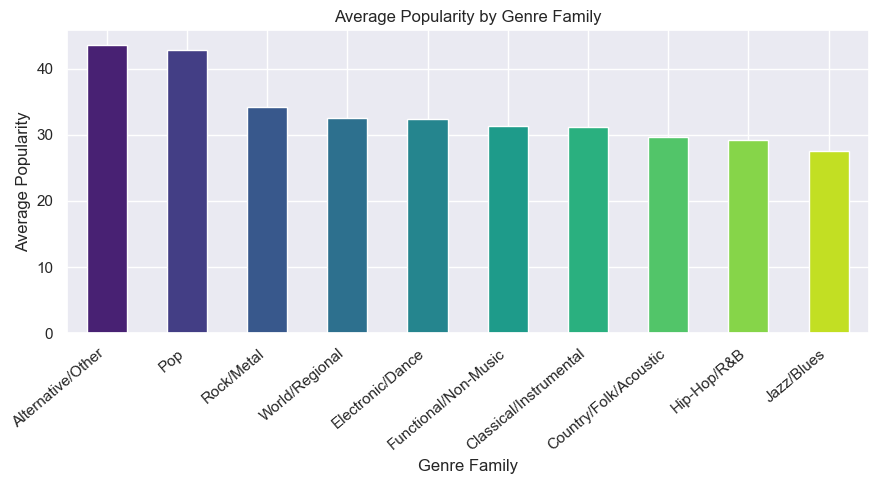

In [30]:
genre_pop = df.groupby('genre_family')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
genre_pop.plot(kind='bar', color=sns.color_palette('viridis', len(genre_pop)))
plt.title('Average Popularity by Genre Family')
plt.xlabel('Genre Family')
plt.ylabel('Average Popularity')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

**Genre explains far more than audio features do.** Alternative/Other and Pop average in the low-to-mid 40s; Jazz/Blues and Hip-Hop/R&B sit in the high-20s — a gap of roughly 15-16 points, dwarfing any correlation we saw with a single feature (~0.09 at most).

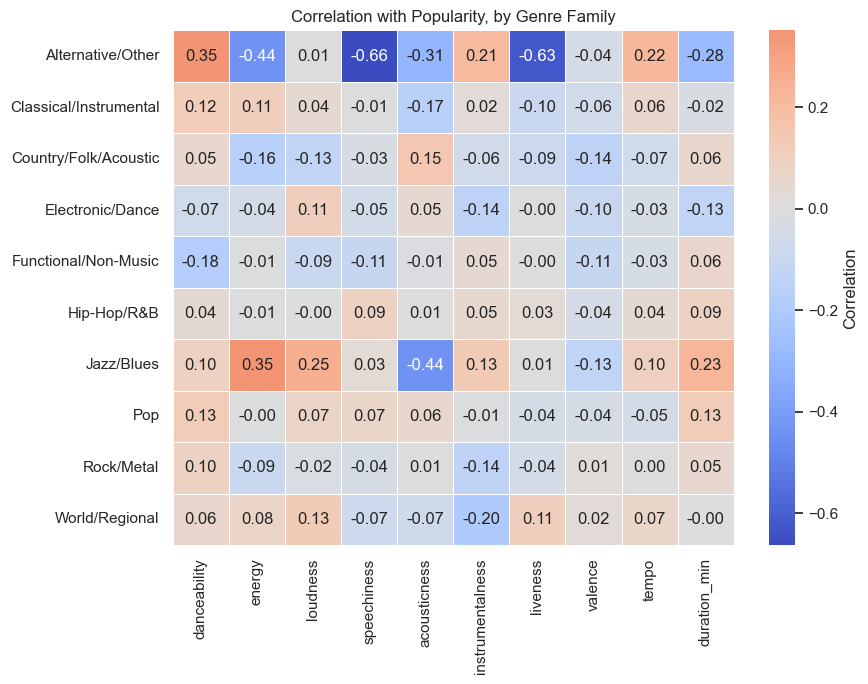

In [31]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                   'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']

genre_corrs = df.groupby('genre_family')[audio_features + ['popularity']].apply(
    lambda g: g.corr()['popularity']
)
genre_corrs = genre_corrs.drop(columns='popularity')

plt.figure(figsize=(9, 7))
sns.heatmap(genre_corrs, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation with Popularity, by Genre Family')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

Genre segmenting reveals moderate linear relationships between audio features and popularity that aren't visible at the whole-dataset level, though few reach a strong correlation. For example, within the Alternative/Other genre family, both speechiness and liveness show strong negative relationships with popularity (-0.66 and -0.63 R scores respectively), and Jazz/Blues shows a moderate negative relationship between acousticness and popularity (-0.44). Beyond these standout cases, most other genre/feature pairs sit in a low-to-moderate range (roughly ±0.1 to ±0.35) — still clearly stronger than the near-zero correlations seen across the entire dataset, even if not dramatic on their own.

## 8. Can we find any common denominators of audio features across the most popular tracks in our dataset?

As we couldn't find many strong linear relationships between audio features and popularity scores, I wanted to investigate which audio features are seen across the most popular tracks in our dataset - the top 1%.

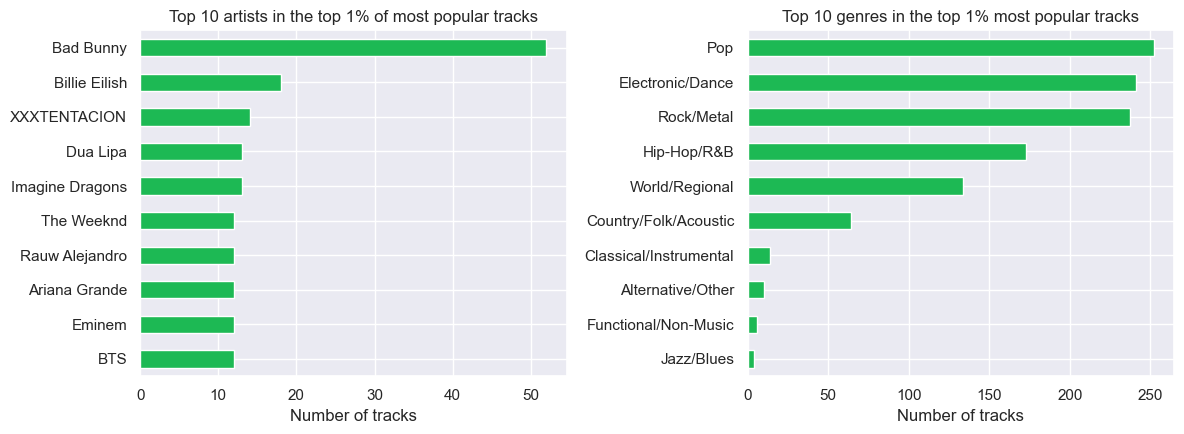

In [32]:
df_top_percent = df.sort_values(by='popularity', ascending=False).drop_duplicates(subset='track_id').head(1135)
df_top_percent['artists'] = df_top_percent['artists'].str.split(";")
df_exploded = df_top_percent.explode('artists')

top_artists = df_exploded.groupby('artists').agg('count')['track_id'].sort_values(ascending=False).head(10)
top_genres = df_top_percent.groupby('genre_family').agg('count')['track_id'].sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
top_artists[::-1].plot(kind='barh', ax=axes[0], color='#1DB954', edgecolor='white')
axes[0].set_title('Top 10 artists in the top 1% of most popular tracks')
axes[0].set_xlabel('Number of tracks')
axes[0].set_ylabel('')

top_genres[::-1].plot(kind='barh', ax=axes[1], color="#1DB954")
axes[1].set_title('Top 10 genres in the top 1% most popular tracks')
axes[1].set_xlabel('Number of tracks')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The top 1% of tracks are dominated by global names such as Bad Bunny, Billie Eilish and XXXTentacion. The tracks released by these artists aren't obscure tracks which happened to have the 'correct' audio profile. This reinforces the idea that popularity isn't driven by audio features alone.

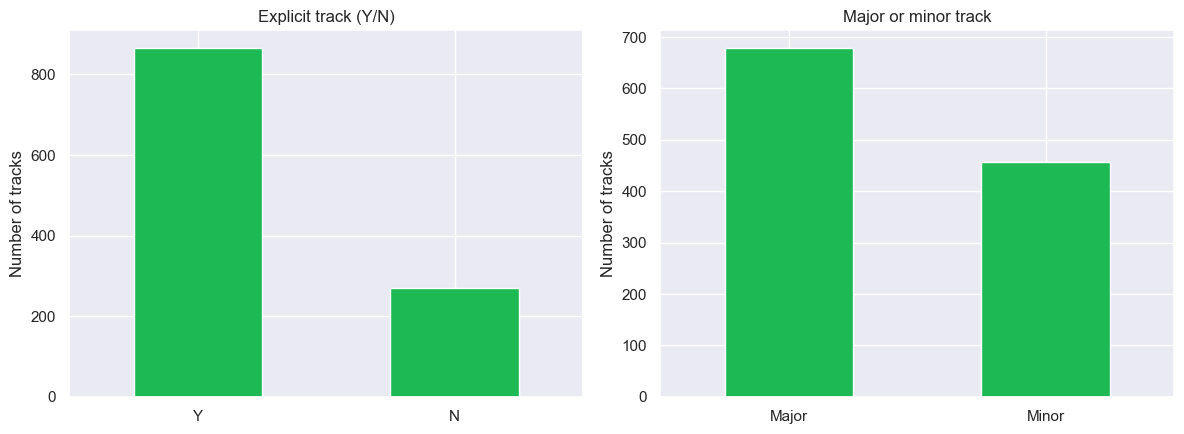

In [33]:
explicit_or_not = df_top_percent.groupby('explicit')['popularity'].agg('count').sort_values(ascending= False).round(2)
major_or_not = df_top_percent.groupby('mode')['popularity'].agg('count').sort_values(ascending= False).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
explicit_or_not.plot(kind='bar', ax=axes[0], color='#1DB954', edgecolor='white')
axes[0].set_title('Explicit track (Y/N)')
axes[0].set_xticklabels(['Y','N'], rotation=0, ha='center')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of tracks')

major_or_not.plot(kind='bar', ax= axes[1], color="#1DB954")
axes[1].set_title('Major or minor track')
axes[1].set_xticklabels(['Major', 'Minor'], rotation=0, ha='center')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of tracks')

plt.tight_layout()
plt.show()

In the top 1% of tracks, 866 are explicit, whereas 269 aren't. This gives a ratio of 3.2 explicit tracks for every 1 non-explicit one. In the full dataset this was a ~10.7:1 non-explicit:explicit split.

This is a reversal from the baseline. Non-explicit tracks dominate the dataset overall, but explicit tracks dominate the top 1% of most popular tracks. Since explicit content skews toward genres like pop, hip-hop, rap and r&b that already tend to perform well on streaming, this may partly reflect genre composition rather than explicit content itself driving popularity.

On the other hand, the ratio of major to minor songs in the top 1% compared to the full dataset changed very little. In the top 1% it was at 1.5:1, whereas in the full dataset this was 1.76:1.

In [34]:
df_median_table = pd.DataFrame({
    'baseline_median': df[audio_features].median(),
    'top1pct_median': df_top_percent[audio_features].median(),
    'pct_difference': (df_top_percent[audio_features].median()-df[audio_features].median())/(df[audio_features].median())
})

df_median_table.style.background_gradient(subset=['pct_difference'], cmap='coolwarm')

,baseline_median,top1pct_median,pct_difference
danceability,0.580000,0.655000,0.129310
energy,0.685000,0.695000,0.014599
loudness,-6.997000,-5.815000,-0.168930
speechiness,0.048900,0.050600,0.034765
acousticness,0.168000,0.103000,-0.386905
instrumentalness,0.000041,0.000003,-0.938257
liveness,0.132000,0.119000,-0.098485
valence,0.464000,0.514000,0.107759
tempo,122.020000,119.938000,-0.017063
duration_min,3.550000,3.450433,-0.028047


To finish this analysis off, I compared the median of each audio feature between the full dataset and the top 1% most popular tracks. The idea being, if there's some "recipe" for a popular song, it should show up here as a big shift in one or more features. For most features (danceability, energy, speechiness, valence, tempo, duration) the shift is small, under 15%, which doesn't point to anything being deliberately tailored to hit the top 1%.

Two of the numbers need a bit of unpacking before taking them at face value though. Instrumentalness's baseline median is basically zero (0.000041), so dividing by that turns a tiny raw difference into a misleading -93.8%. And loudness is negative to begin with, which flips how the percentage reads. Even though it shows -16.9%, the top 1%'s median loudness (-5.815) is actually louder than baseline (-6.997), not quieter, since loudness gets less negative as volume increases.

Once you account for those two, this backs up what the correlation sections already suggested — there's no real evidence that popular tracks are built to a specific audio formula.

## 9. Key Findings

**1. Individual audio features don't predict popularity.** Every audio feature — danceability, energy, loudness, and the rest — correlates with popularity at under 0.1 in magnitude (the strongest, instrumentalness, is only -0.09), so popularity isn't simply "more danceable = more popular." Comparing median audio feature values between the full dataset and the top 1% most popular tracks confirmed this: none showed a meaningful shift, meaning popular songs don't follow a distinct audio profile. Segmenting by genre family did surface some moderate relationships invisible at the whole-dataset level, but not enough to suggest that mixing genres together had been masking a strong underlying trend.

**2. Audio features correlate with each other, even where none correlate with popularity**. Loudness and energy move together closely (r = 0.76), as do valence and danceability (r = 0.48), while acousticness trends strongly opposite to both energy (r = -0.73) and loudness (r = -0.59). These are the strongest relationships found anywhere in the dataset — far exceeding any feature's link to popularity. 

**3. Genre is a far stronger signal than any single audio feature.** Average popularity ranges from ~27-29 (Jazz/Blues, Hip-Hop/R&B) to ~42-44 (Pop, Alternative/Other). This represents a gap of roughly 15-16 points, versus correlations of ~0.09 for individual features.

**4. Takeaway for a hypothetical playlist/marketing team:** don't optimise a track's audio profile to chase popularity — the data doesn't support that strategy. Popularity looks driven mostly by factors outside this dataset (artist recognition, playlist placement, release timing).

**Caveats:** this dataset has one row per (track, genre) pair, not one row per unique song, and genres are artificially balanced at ~1,000 tracks each. Real-world genre popularity shares would look different on organic streaming data.